In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install gdown


In [3]:
!gdown 1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ

# https://drive.google.com/file/d/1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ/view?usp=drive_link
# https://drive.google.com/file/d/1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ/view?usp=drive_link

Downloading...
From (original): https://drive.google.com/uc?id=1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ
From (redirected): https://drive.google.com/uc?id=1VGm-hWxktQp978mc6rEbkn9eDxo7zBRZ&confirm=t&uuid=56163073-ab23-465a-9c38-0f089bc39c4f
To: /content/suitesparse_kaggle_export.zip
100% 1.72G/1.72G [00:28<00:00, 59.6MB/s]


In [4]:

!unzip -o suitesparse_kaggle_export.zip

Streaming output truncated to the last 5000 lines.
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1642.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1643.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1644.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1645.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1646.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1647.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1648.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_1649.txt  
  inflating: suitesparse_mtx/Moqri/MISKnowledgeMap/MISKnowledgeMap/MISKnowledgeMap_Abstract_165.txt  
  inflating: suitespars

In [5]:
!pip install ssgetpy -q


In [6]:
import torch
import numpy as np
import random
import os
import cupy as cp

seed = 42

os.environ["PYTHONHASHSEED"] = str(seed)

torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

np.random.seed(seed)
random.seed(seed)
cp.random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("All seeds set to 42 for reproducibility")

All seeds set to 42 for reproducibility


In [7]:
import json
import ssgetpy
from pathlib import Path

data_dir = Path("suitesparse_mtx")

# Load the saved metadata
with open("suitesparse_selected.json") as f:
    meta = json.load(f)

print("Matrices listed in JSON:", len(meta))

# Rebuild selected list exactly as in kaggle
selected = []
for item in meta:
    g = item["group"]
    n = item["name"]
    try:
        # Fetch the exact matrix entry from SuiteSparse DB metadata
        m = ssgetpy.search(group=g, name=n, limit=1)[0]
        selected.append(m)
    except:
        print("Could not find:", g, n)

print("Reconstructed selected list:", len(selected))


Matrices listed in JSON: 1765
Reconstructed selected list: 1765


In [8]:
from pathlib import Path
import scipy.io
import scipy.sparse as sp
import numpy as np

data_dir = Path("suitesparse_mtx")

def load_matrix_metadata(m):
    """
    Given an ssgetpy Matrix object m (with .group and .name),
    recursively find a .mtx file under suitesparse_mtx/group/name/,
    load it as SciPy CSR (float64), and return it.
    """
    base_dir = data_dir / m.group / m.name

    if not base_dir.exists():
        print(f"[WARN] Directory not found for {m.group}/{m.name}: {base_dir}")
        return None

    # Recursively search for any .mtx file
    mtx_file = None
    for f in base_dir.rglob("*.mtx"):
        mtx_file = f
        break  # first match

    if mtx_file is None:
        print(f"[WARN] No .mtx file found under {base_dir}")
        return None

    print(f"Loading {m.group}/{m.name} from {mtx_file.relative_to(data_dir)}")
    A = scipy.io.mmread(str(mtx_file))
    A = A.tocsr().astype(np.float64)   # ensure CSR float64

    print(f"  shape: {A.shape}, nnz: {A.nnz}, dtype: {A.dtype}")
    return A

# Test on first 3 matrices
print("Testing loader on a few matrices...")
for m in selected[:3]:
    A = load_matrix_metadata(m)
    print("-" * 60)


Testing loader on a few matrices...
Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
------------------------------------------------------------
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
------------------------------------------------------------
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
------------------------------------------------------------


In [9]:
# Install CuPy for CUDA 12 (works on current Colab GPUs)
!pip install -q cupy-cuda12x

import cupyx.scipy.sparse as cpsp
import cupy as cp
import time
import scipy.sparse as sp
import numpy as np

def scipy_to_cupy_csr(A, dtype=cp.float64):
    """
    Convert a SciPy CSR matrix A to a CuPy CSR matrix with given dtype.
    """
    A = A.tocsr()
    data   = cp.asarray(A.data,   dtype=dtype)
    indices = cp.asarray(A.indices, dtype=cp.int32)
    indptr  = cp.asarray(A.indptr,  dtype=cp.int32)
    return cpsp.csr_matrix((data, indices, indptr), shape=A.shape)

def gpu_reference_spmv(A, n_runs=5):
    """
    Reference SpMV on GPU in float64 precision.

    Returns:
        A64_gpu : CuPy CSR (float64)
        x_ref   : CuPy dense vector (float64)
        y_ref   : CuPy dense vector (float64)
        avg_t   : average execution time over n_runs (seconds)
    """
    # 1) Move A to GPU in float64
    A64_gpu = scipy_to_cupy_csr(A, dtype=cp.float64)

    n = A.shape[1]
    cp.random.seed(42)
    x_ref = cp.random.randn(n, dtype=cp.float64)

    # 2) Warm-up (to avoid including one-time overhead)
    _ = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    # 3) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_ref = A64_gpu @ x_ref
    cp.cuda.Stream.null.synchronize()

    avg_t = (time.time() - t0) / n_runs
    return A64_gpu, x_ref, y_ref, avg_t

# Quick sanity test on the first matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Test matrix: {m_test.group}/{m_test.name}")
print("  shape:", A_test.shape, "nnz:", A_test.nnz)
print(f"  Reference GPU SpMV avg time: {t_ref:.6e} s")
print("  ||y_ref|| (L2 norm):", float(cp.linalg.norm(y_ref)))


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Test matrix: HB/1138_bus
  shape: (1138, 1138) nnz: 4054
  Reference GPU SpMV avg time: 1.356602e-04 s
  ||y_ref|| (L2 norm): 127943.06436550368


In [10]:
import scipy.sparse as sp

def build_entrywise_matrices(A, thresh=1.0):
    """
    Split entries of A by magnitude:

      - A_hi: |a_ij| >= thresh
      - A_lo: |a_ij| <  thresh

    Returns two SciPy CSR matrices.
    """
    A = A.tocoo()
    data = A.data
    rows = A.row
    cols = A.col

    mask_hi = np.abs(data) >= thresh
    mask_lo = ~mask_hi

    A_hi = sp.coo_matrix((data[mask_hi], (rows[mask_hi], cols[mask_hi])),
                         shape=A.shape).tocsr()
    A_lo = sp.coo_matrix((data[mask_lo], (rows[mask_lo], cols[mask_lo])),
                         shape=A.shape).tocsr()
    return A_hi, A_lo

def eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0, n_runs=5):
    """
    Entry-wise mixed precision SpMV:

      - A_hi stored and multiplied in float64
      - A_lo stored and multiplied in float32
      - Both results accumulated in float64

    A: SciPy sparse matrix (CSR/COO/etc)
    x_ref, y_ref: CuPy vectors from gpu_reference_spmv
    """
    # 1) Split into high/low magnitude matrices on CPU
    A_hi, A_lo = build_entrywise_matrices(A, thresh=thresh)

    # 2) Move to GPU with desired precisions
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    # 3) Prepare x in both precisions
    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 4) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 5) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32
        y    = y_hi + y_lo.astype(cp.float64)
    cp.cuda.Stream.null.synchronize()
    avg_t = (time.time() - t0) / n_runs

    # 6) Relative error vs reference
    rel_err = cp.linalg.norm(y - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

#  Quick test on the same test matrix as before
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_entry, e_entry = eval_entrywise_spmv(A_test, x_ref, y_ref, thresh=1.0)
print(f"Entry-wise time: {t_entry:.6e} s,  rel_err = {e_entry:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 1.063347e-04 s
Entry-wise time: 3.991084e-02 s,  rel_err = 8.356e-13


In [11]:
def build_rowwise_matrices(A, p=0.8, f=0.5):
    """
    Row-wise split based on percentage of small values.

    A row is assigned FP32 if at least p fraction of its values
    lie within range (-r, r).

    r = f * mean(|A|)
    """

    A = A.tocsr()

    data = A.data
    indptr = A.indptr

    # Compute matrix-specific range r
    # r = f * np.mean(np.abs(data))
    mean_val = np.mean(np.abs(data))

    if mean_val == 0:
      r = 1e-12
    else:
      r = f * mean_val

    hi_rows = []
    lo_rows = []

    for i in range(A.shape[0]):

        s = indptr[i]
        e = indptr[i+1]

        if s == e:
            lo_rows.append(i)
            continue

        row_vals = np.abs(data[s:e])

        frac_small = np.sum(row_vals < r) / len(row_vals)

        if frac_small >= p:
            lo_rows.append(i)   # FP32
        else:
            hi_rows.append(i)   # FP64

    hi_rows = np.array(hi_rows)
    lo_rows = np.array(lo_rows)

    # A_hi = A[hi_rows, :]
    # A_lo = A[lo_rows, :]

    # Ensure both partitions exist
    if len(hi_rows) == 0:
        hi_rows = lo_rows[:1]

    if len(lo_rows) == 0:
        lo_rows = hi_rows[:1]

    A_hi = A[hi_rows, :]
    A_lo = A[lo_rows, :]

    return A_hi, A_lo, hi_rows, lo_rows


def eval_rowwise_spmv(A, x_ref, y_ref, p=0.8, f=0.5, n_runs=5):

    A_hi, A_lo, hi_idx, lo_idx = build_rowwise_matrices(A, p=p, f=f)

    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # warmup
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    t0 = time.time()

    for _ in range(n_runs):

        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32

    cp.cuda.Stream.null.synchronize()

    avg_t = (time.time() - t0) / n_runs

    # reconstruct output
    y_full = cp.zeros_like(y_ref)

    y_full[hi_idx] = y_hi
    y_full[lo_idx] = y_lo.astype(cp.float64)

    rel_err = cp.linalg.norm(y_full - y_ref) / cp.linalg.norm(y_ref)

    return avg_t, float(rel_err)

In [12]:
def build_adaptive_matrices(A, quantile=0.7):
    """
    2-bucket adaptive split by |a_ij|:
      - A_hi: entries >= quantile(|a|)
      - A_lo: entries <  quantile(|a|)
    """
    A = A.tocoo()
    data = A.data
    rows = A.row
    cols = A.col

    abs_data = np.abs(data)
    if abs_data.size == 0:
        Z = sp.csr_matrix(A.shape, dtype=np.float64)
        return Z, Z

    thresh = np.quantile(abs_data, quantile)

    mask_hi = abs_data >= thresh
    mask_lo = abs_data <  thresh

    A_hi = sp.coo_matrix((data[mask_hi], (rows[mask_hi], cols[mask_hi])),
                         shape=A.shape).tocsr()
    A_lo = sp.coo_matrix((data[mask_lo], (rows[mask_lo], cols[mask_lo])),
                         shape=A.shape).tocsr()

    return A_hi, A_lo

def eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7, n_runs=5):
    """
    Adaptive mixed precision SpMV:

      - High bucket (>= quantile) -> float64
      - Low bucket  (< quantile)  -> float32
    """
    # 1) Build high/low matrices
    A_hi, A_lo = build_adaptive_matrices(A, quantile=quantile)

    # 2) Move to GPU with desired precision
    A_hi_gpu = scipy_to_cupy_csr(A_hi, dtype=cp.float64)
    A_lo_gpu = scipy_to_cupy_csr(A_lo, dtype=cp.float32)

    x64 = x_ref
    x32 = x_ref.astype(cp.float32)

    # 3) Warm-up
    _ = A_hi_gpu @ x64
    _ = A_lo_gpu @ x32
    cp.cuda.Stream.null.synchronize()

    # 4) Timed runs
    t0 = time.time()
    for _ in range(n_runs):
        y_hi = A_hi_gpu @ x64
        y_lo = A_lo_gpu @ x32
        y    = y_hi + y_lo.astype(cp.float64)
    cp.cuda.Stream.null.synchronize()

    avg_t  = (time.time() - t0) / n_runs
    rel_err = cp.linalg.norm(y - y_ref) / cp.linalg.norm(y_ref)
    return avg_t, float(rel_err)

# Quick test on the same test matrix
m_test = selected[0]
A_test = load_matrix_metadata(m_test)

A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A_test)
print(f"Reference time (float64): {t_ref:.6e} s")

t_adapt, e_adapt = eval_adaptive_spmv(A_test, x_ref, y_ref, quantile=0.7)
print(f"Adaptive time: {t_adapt:.6e} s,  rel_err = {e_adapt:.3e}")


Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Reference time (float64): 8.387566e-05 s
Adaptive time: 2.193928e-04 s,  rel_err = 6.871e-10


In [13]:
all_matrices = []

# Step 1: Add original matrices
for m in selected:
    all_matrices.append({
        "type": "original",
        "matrix": m
    })

print("Original matrices:", len(all_matrices))

Original matrices: 1765


In [14]:
print(len(selected))
print(len(all_matrices))

1765
1765


In [15]:
import json
from tqdm.auto import tqdm

err_tol = 1e-3

labels = {}
stats = {}

# Store matrices by class (very important for upsampling later)
class_matrices = {
    0: [],  # Entry-wise
    1: [],  # Row-wise
    2: []   # Adaptive
}

skipped_error = []

print("Starting labeling process...")

for item in tqdm(all_matrices, desc="Labeling matrices"):

    try:

        # --------------------------------------------------
        # Handle original vs augmented matrices
        # --------------------------------------------------

        if item["type"] == "original":

            m = item["matrix"]
            name = f"{m.group}/{m.name}"
            A = load_matrix_metadata(m)

        else:

            name = item["name"]
            A = item["matrix"]

        if A is None:
            skipped_error.append(name)
            continue


        # --------------------------------------------------
        # Reference FP64 computation
        # --------------------------------------------------

        A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A)


        # --------------------------------------------------
        # Evaluate precision strategies
        # --------------------------------------------------

        t_ent, e_ent = eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0)
        t_row, e_row = eval_rowwise_spmv(A, x_ref, y_ref)
        t_adp, e_adp = eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7)


        methods = [
            {"name": "entrywise", "time": t_ent, "err": e_ent, "label": 0},
            {"name": "rowwise",   "time": t_row, "err": e_row, "label": 1},
            {"name": "adaptive",  "time": t_adp, "err": e_adp, "label": 2},
        ]


        # --------------------------------------------------
        # Store stats
        # --------------------------------------------------

        stats[name] = methods


        # --------------------------------------------------
        # Select label
        # --------------------------------------------------

        feasible = [m for m in methods if m["err"] <= err_tol]

        if feasible:
            best = min(feasible, key=lambda d: d["time"])
        else:
            best = min(methods, key=lambda d: d["err"])

        label = best["label"]
        labels[name] = label

        # --------------------------------------------------
        # Store matrix by class (IMPORTANT)
        # --------------------------------------------------

        class_matrices[label].append({
            "name": name,
            "matrix": A
        })


    except Exception as e:

        print(f"[ERROR] {name}: {e}")
        skipped_error.append(name)
        continue


# --------------------------------------------------
# Save labeling results
# --------------------------------------------------

with open("labels.json", "w") as f:
    json.dump(labels, f, indent=2)

with open("stats.json", "w") as f:
    json.dump(stats, f, indent=2)


print("\nLabeling completed.")
print("Labeled matrices:", len(labels))

print(
    "Label distribution:",
    {lbl: len(class_matrices[lbl]) for lbl in class_matrices}
)

print("Skipped matrices:", len(skipped_error))

Starting labeling process...


Labeling matrices:   0%|          | 0/1765 [00:00<?, ?it/s]

Loading HB/1138_bus from HB/1138_bus/1138_bus/1138_bus.mtx
  shape: (1138, 1138), nnz: 4054, dtype: float64
Loading HB/494_bus from HB/494_bus/494_bus/494_bus.mtx
  shape: (494, 494), nnz: 1666, dtype: float64
Loading HB/662_bus from HB/662_bus/662_bus/662_bus.mtx
  shape: (662, 662), nnz: 2474, dtype: float64
Loading HB/685_bus from HB/685_bus/685_bus/685_bus.mtx
  shape: (685, 685), nnz: 3249, dtype: float64
Loading HB/arc130 from HB/arc130/arc130/arc130.mtx
  shape: (130, 130), nnz: 1282, dtype: float64
Loading HB/bcsstk01 from HB/bcsstk01/bcsstk01/bcsstk01.mtx
  shape: (48, 48), nnz: 400, dtype: float64
Loading HB/bcsstk02 from HB/bcsstk02/bcsstk02/bcsstk02.mtx
  shape: (66, 66), nnz: 4356, dtype: float64
Loading HB/bcsstk03 from HB/bcsstk03/bcsstk03/bcsstk03.mtx
  shape: (112, 112), nnz: 640, dtype: float64
Loading HB/bcsstk04 from HB/bcsstk04/bcsstk04/bcsstk04.mtx
  shape: (132, 132), nnz: 3648, dtype: float64
Loading HB/bcsstk05 from HB/bcsstk05/bcsstk05/bcsstk05.mtx
  shape: (1

In [16]:
import numpy as np
import scipy.sparse as sp


# --------------------------------------------------
# Entry-wise augmentation
# Creates magnitude outliers → encourages entry-wise split
# --------------------------------------------------
def augment_entrywise(A):
    A = A.tocoo()

    data = A.data.copy()
    rows = A.row
    cols = A.col

    if len(data) == 0:
        return A.tocsr()

    # Only slightly increase some values
    mask = np.random.rand(len(data)) < 0.05
    data[mask] *= np.random.uniform(2, 5)

    return sp.coo_matrix((data, (rows, cols)), shape=A.shape).tocsr()


# --------------------------------------------------
# Adaptive augmentation
# Creates row magnitude variation → encourages adaptive split
# --------------------------------------------------
def augment_adaptive(A):
    A = A.tocsr().copy()
    n_rows = A.shape[0]

    # Only scale very few rows slightly
    for i in range(n_rows):
        if np.random.rand() < 0.1:
            scale = np.random.uniform(0.8, 1.2)
            start = A.indptr[i]
            end = A.indptr[i + 1]
            A.data[start:end] *= scale

    return A


# --------------------------------------------------
# Structure-preserving augmentation
# Does not significantly change label
# --------------------------------------------------
def augment_structure(A):
    choice = np.random.choice(["row_perm", "col_perm", "scale", "noise"])

    if choice == "row_perm":
        perm = np.random.permutation(A.shape[0])
        return A[perm, :].tocsr()

    elif choice == "col_perm":
        perm = np.random.permutation(A.shape[1])
        return A[:, perm].tocsr()

    elif choice == "scale":
        return (A * np.random.uniform(0.8, 1.2)).tocsr()

    elif choice == "noise":
        A = A.tocoo()
        data = A.data.copy()
        noise = np.random.normal(0, 0.01, size=len(data))
        data = data + noise
        return sp.coo_matrix((data, (A.row, A.col)), shape=A.shape).tocsr()


# --------------------------------------------------
# Master augmentation function
# --------------------------------------------------
def augment_matrix_for_class(A, target_class):

    if target_class == 0:
        return augment_entrywise(A)

    elif target_class == 2:
        return augment_adaptive(A)

    else:
        return augment_structure(A)

In [17]:
# import random

# target_class_0 = 1000
# target_class_2 = 1000

# print("Before upsampling:")
# print("Class 0:", len(class_matrices[0]))
# print("Class 1:", len(class_matrices[1]))
# print("Class 2:", len(class_matrices[2]))

# def relabel_matrix(A):
#     A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A)

#     t_ent, e_ent = eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0)
#     t_row, e_row = eval_rowwise_spmv(A, x_ref, y_ref)
#     t_adp, e_adp = eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7)

#     methods = [
#         {"time": t_ent, "err": e_ent, "label": 0},
#         {"time": t_row, "err": e_row, "label": 1},
#         {"time": t_adp, "err": e_adp, "label": 2},
#     ]

#     feasible = [m for m in methods if m["err"] <= 1e-3]

#     if feasible:
#         best = min(feasible, key=lambda d: d["time"])
#     else:
#         best = min(methods, key=lambda d: d["err"])

#     return best["label"]


# # --------------------------------------------------
# # Upsample Entry-wise (Class 0)
# # --------------------------------------------------
# print("\nUpsampling class 0...")

# while len(class_matrices[0]) < target_class_0:

#     sample = random.choice(class_matrices[0])
#     A = sample["matrix"]

#     A_aug = augment_matrix_for_class(A, 0)
#     new_label = relabel_matrix(A_aug)

#     if new_label == 0:
#         class_matrices[0].append({
#             "name": f"aug_entry_{len(class_matrices[0])}",
#             "matrix": A_aug
#         })


# # --------------------------------------------------
# # Upsample Adaptive (Class 2)
# # --------------------------------------------------
# print("Upsampling class 2...")

# while len(class_matrices[2]) < target_class_2:

#     sample = random.choice(class_matrices[2])
#     A = sample["matrix"]

#     A_aug = augment_matrix_for_class(A, 2)
#     new_label = relabel_matrix(A_aug)

#     if new_label == 2:
#         class_matrices[2].append({
#             "name": f"aug_adapt_{len(class_matrices[2])}",
#             "matrix": A_aug
#         })


# print("\nAfter upsampling:")
# print("Class 0:", len(class_matrices[0]))
# print("Class 1:", len(class_matrices[1]))
# print("Class 2:", len(class_matrices[2]))

In [18]:
import random

target_class_0 = 800
target_class_2 = 800
max_attempts = 1000000

print("Before upsampling:")
print("Class 0:", len(class_matrices[0]))
print("Class 1:", len(class_matrices[1]))
print("Class 2:", len(class_matrices[2]))


def relabel_matrix(A):
    A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A)

    t_ent, e_ent = eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0)
    t_row, e_row = eval_rowwise_spmv(A, x_ref, y_ref)
    t_adp, e_adp = eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7)

    methods = [
        {"time": t_ent, "err": e_ent, "label": 0},
        {"time": t_row, "err": e_row, "label": 1},
        {"time": t_adp, "err": e_adp, "label": 2},
    ]

    feasible = [m for m in methods if m["err"] <= 1e-3]

    if feasible:
        best = min(feasible, key=lambda d: d["time"])
    else:
        best = min(methods, key=lambda d: d["err"])

    return best["label"]


# --------------------------------------------------
# Upsample Class 0
# --------------------------------------------------
print("\nUpsampling class 0...")
attempts = 0
accepted = 0

while len(class_matrices[0]) < target_class_0 and attempts < max_attempts:

    sample = random.choice(class_matrices[0])
    A = sample["matrix"]

    # Skip very large matrices (too slow)
    if A.nnz > 200000:
        attempts += 1
        continue

    A_aug = augment_matrix_for_class(A, 0)
    new_label = relabel_matrix(A_aug)

    attempts += 1

    if new_label == 0:
        class_matrices[0].append({
            "name": f"aug_entry_{len(class_matrices[0])}",
            "matrix": A_aug
        })
        accepted += 1

print(f"Class 0 accepted: {accepted}/{attempts}")


# --------------------------------------------------
# Upsample Class 2
# --------------------------------------------------
print("\nUpsampling class 2...")
attempts = 0
accepted = 0

while len(class_matrices[2]) < target_class_2 and attempts < max_attempts:

    sample = random.choice(class_matrices[2])
    A = sample["matrix"]

    if A.nnz > 200000:
        attempts += 1
        continue

    A_aug = augment_matrix_for_class(A, 2)
    new_label = relabel_matrix(A_aug)

    attempts += 1

    if new_label == 2:
        class_matrices[2].append({
            "name": f"aug_adapt_{len(class_matrices[2])}",
            "matrix": A_aug
        })
        accepted += 1

print(f"Class 2 accepted: {accepted}/{attempts}")


print("\nAfter upsampling:")
print("Class 0:", len(class_matrices[0]))
print("Class 1:", len(class_matrices[1]))
print("Class 2:", len(class_matrices[2]))

Before upsampling:
Class 0: 100
Class 1: 1072
Class 2: 67

Upsampling class 0...
Class 0 accepted: 700/7949

Upsampling class 2...
Class 2 accepted: 733/18704

After upsampling:
Class 0: 800
Class 1: 1072
Class 2: 800


In [19]:
# balanced_dataset = []

# for c in [0,1,2]:
#     for item in class_matrices[c]:
#         balanced_dataset.append({
#             "matrix": item["matrix"],
#             "label": c,
#             "name": item["name"]
#         })

balanced_dataset = []

for c in [0,1,2]:
    for item in class_matrices[c]:
        balanced_dataset.append({
            "matrix": item["matrix"],
            "label": c,
            "name": item["name"]
        })

import random
random.shuffle(balanced_dataset)

from collections import Counter
labels = [item["label"] for item in balanced_dataset]
print("Final dataset distribution:", Counter(labels))
print("Total samples:", len(balanced_dataset))

Final dataset distribution: Counter({1: 1072, 2: 800, 0: 800})
Total samples: 2672


In [20]:
import numpy as np
import scipy.sparse as sp
from tqdm.auto import tqdm

# --------------------------------------------------
# Distance Histogram Representation
# --------------------------------------------------
def sparse_to_histogram(A, H=160, W_half=80):

    A = A.tocoo()
    M, N = A.shape

    if A.nnz == 0:
        return np.zeros((H, W_half * 2), dtype=np.float32)

    rows = A.row.astype(np.float64)
    cols = A.col.astype(np.float64)

    dists = np.abs(rows - cols)
    max_dist = max(M, N)

    r_bin = np.floor((rows * H) / max(M, 1)).astype(np.int32)
    r_bin = np.clip(r_bin, 0, H - 1)

    c_bin = np.floor((cols * H) / max(N, 1)).astype(np.int32)
    c_bin = np.clip(c_bin, 0, H - 1)

    d_bin = np.floor((dists * W_half) / max(max_dist, 1)).astype(np.int32)
    d_bin = np.clip(d_bin, 0, W_half - 1)

    vals = np.log1p(np.abs(A.data)).astype(np.float32)

    row_hist = sp.coo_matrix((vals, (r_bin, d_bin)), shape=(H, W_half)).toarray()
    col_hist = sp.coo_matrix((vals, (c_bin, d_bin)), shape=(H, W_half)).toarray()

    if row_hist.max() > 0:
        row_hist /= row_hist.max()
    if col_hist.max() > 0:
        col_hist /= col_hist.max()

    combined_hist = np.hstack([row_hist, col_hist])

    return combined_hist.astype(np.float32)


# --------------------------------------------------
# Build dataset from BALANCED dataset
# --------------------------------------------------
X_list = []
y_list = []
name_list = []

print("Generating histograms from balanced dataset...")

for item in tqdm(balanced_dataset, desc="Building Histograms"):

    try:
        A = item["matrix"]
        label = item["label"]
        name = item["name"]

        hist_img = sparse_to_histogram(A)

        X_list.append(hist_img)
        y_list.append(label)
        name_list.append(name)

    except Exception as e:
        print(f"Skipping {name}: {e}")
        continue


# --------------------------------------------------
# Save dataset
# --------------------------------------------------
X = np.stack(X_list, axis=0).astype(np.float32)
y = np.array(y_list, dtype=np.int64)

print("-" * 30)
print("Balanced Histogram Dataset:")
print(f"  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print("  Class counts:", {int(k): int((y == k).sum()) for k in np.unique(y)})

np.save("X_raw.npy", X)
np.save("y_raw.npy", y)

Generating histograms from balanced dataset...


Building Histograms:   0%|          | 0/2672 [00:00<?, ?it/s]

------------------------------
Balanced Histogram Dataset:
  X shape: (2672, 160, 160)
  y shape: (2672,)
  Class counts: {0: 800, 1: 1072, 2: 800}


In [21]:
import random

def relabel_matrix(A):
    A64_gpu, x_ref, y_ref, t_ref = gpu_reference_spmv(A)

    t_ent, e_ent = eval_entrywise_spmv(A, x_ref, y_ref, thresh=1.0)
    t_row, e_row = eval_rowwise_spmv(A, x_ref, y_ref)
    t_adp, e_adp = eval_adaptive_spmv(A, x_ref, y_ref, quantile=0.7)

    methods = [
        {"time": t_ent, "err": e_ent, "label": 0},
        {"time": t_row, "err": e_row, "label": 1},
        {"time": t_adp, "err": e_adp, "label": 2},
    ]

    feasible = [m for m in methods if m["err"] <= 1e-3]

    if feasible:
        best = min(feasible, key=lambda d: d["time"])
    else:
        best = min(methods, key=lambda d: d["err"])

    return best["label"]


# --------------------------------------------------
# Validate augmented matrices
# --------------------------------------------------
print("Validating augmented matrices...")

check_samples = 50
correct = 0
total = 0

for cls in [0, 2]:
    samples = random.sample(class_matrices[cls], min(check_samples, len(class_matrices[cls])))

    for item in samples:
        A = item["matrix"]
        new_label = relabel_matrix(A)

        if new_label == cls:
            correct += 1
        total += 1

print(f"Label preservation accuracy: {correct}/{total} = {correct/total:.2f}")

Validating augmented matrices...
Label preservation accuracy: 16/100 = 0.16


In [22]:
import numpy as np

# Load histogram dataset
X = np.load("X_raw.npy")      # shape: (N, 128, 128)
y = np.load("y_raw.npy")      # shape: (N,)

print("Histogram Dataset Shape:", X.shape)
print("Labels Shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)
print("Class distribution:")
for c, cnt in zip(unique, counts):
    print(f"  class {c}: {cnt}")

Histogram Dataset Shape: (2672, 160, 160)
Labels Shape: (2672,)
Class distribution:
  class 0: 800
  class 1: 1072
  class 2: 800


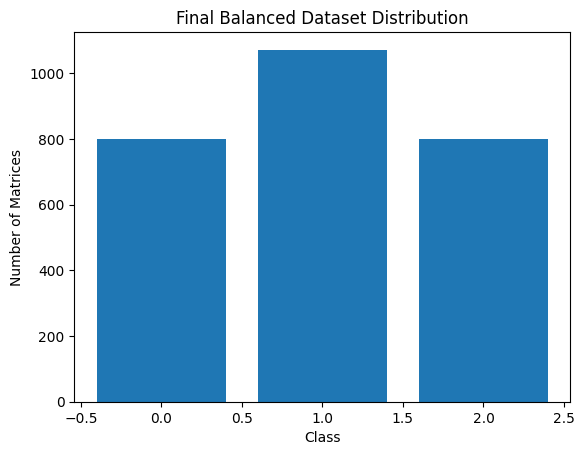

In [23]:
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)

plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Number of Matrices")
plt.title("Final Balanced Dataset Distribution")
plt.show()

In [24]:
# import torch
# import numpy as np
# from torch.utils.data import TensorDataset, DataLoader
# from sklearn.model_selection import train_test_split

# print("Final dataset shape:", X.shape, y.shape)

# # Convert to tensors; add channel dim (N, 1, 128, 128)
# X_t = torch.from_numpy(X).unsqueeze(1).float()
# y_t = torch.from_numpy(y).long()

# # Stratified split
# train_idx, val_idx = train_test_split(
#     np.arange(len(y)),
#     test_size=0.2,
#     stratify=y,
#     random_state=42
# )

# train_ds = TensorDataset(X_t[train_idx], y_t[train_idx])
# val_ds   = TensorDataset(X_t[val_idx], y_t[val_idx])

# print("Total samples:", len(X))
# print("Train size:", len(train_ds))
# print("Val size:", len(val_ds))

# # Print class distribution
# print("\nTrain distribution:")
# train_labels = y[train_idx]
# unique, counts = np.unique(train_labels, return_counts=True)
# for u, c in zip(unique, counts):
#     print(f"  class {u}: {c}")

# print("\nValidation distribution:")
# val_labels = y[val_idx]
# unique, counts = np.unique(val_labels, return_counts=True)
# for u, c in zip(unique, counts):
#     print(f"  class {u}: {c}")

# batch_size = 32

# train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
# val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

print("Final dataset shape:", X.shape, y.shape)

# --------------------------------------------------
# Convert to tensors and add channel dimension
# (N, 128, 128) -> (N, 1, 128, 128)
# --------------------------------------------------
X_t = torch.from_numpy(X).unsqueeze(1).float()
y_t = torch.from_numpy(y).long()

# --------------------------------------------------
# Stratified Train / Val / Test split (70 / 15 / 15)
# --------------------------------------------------
indices = np.arange(len(y))

# First split: Train (70%) and Temp (30%)
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=y,
    random_state=42
)

# Second split: Validation (15%) and Test (15%)
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=y[temp_idx],
    random_state=42
)

# --------------------------------------------------
# Create datasets
# --------------------------------------------------
train_ds = TensorDataset(X_t[train_idx], y_t[train_idx])
val_ds   = TensorDataset(X_t[val_idx], y_t[val_idx])
test_ds  = TensorDataset(X_t[test_idx], y_t[test_idx])

print("\nDataset sizes:")
print("Total samples:", len(X))
print("Train size:", len(train_ds))
print("Validation size:", len(val_ds))
print("Test size:", len(test_ds))

# --------------------------------------------------
# Print class distribution
# --------------------------------------------------
def print_distribution(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        print(f"  class {u}: {c}")

print_distribution("Train", y[train_idx])
print_distribution("Validation", y[val_idx])
print_distribution("Test", y[test_idx])

# --------------------------------------------------
# DataLoaders
# --------------------------------------------------
batch_size = 32

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

print("\nDataLoaders ready.")

Final dataset shape: (2672, 160, 160) (2672,)

Dataset sizes:
Total samples: 2672
Train size: 1870
Validation size: 401
Test size: 401

Train distribution:
  class 0: 560
  class 1: 750
  class 2: 560

Validation distribution:
  class 0: 120
  class 1: 161
  class 2: 120

Test distribution:
  class 0: 120
  class 1: 161
  class 2: 120

DataLoaders ready.


In [25]:
def print_class_distribution(y, indices, name):
    subset = y[indices]
    unique, counts = np.unique(subset, return_counts=True)
    total = len(subset)

    print(f"\n{name} distribution:")
    for u, c in zip(unique, counts):
        print(f"  class {u}: {c} ({c/total:.2%})")

# Print distributions
print_class_distribution(y, train_idx, "Train")
print_class_distribution(y, val_idx, "Validation")
print_class_distribution(y, test_idx, "Test")


Train distribution:
  class 0: 560 (29.95%)
  class 1: 750 (40.11%)
  class 2: 560 (29.95%)

Validation distribution:
  class 0: 120 (29.93%)
  class 1: 161 (40.15%)
  class 2: 120 (29.93%)

Test distribution:
  class 0: 120 (29.93%)
  class 1: 161 (40.15%)
  class 2: 120 (29.93%)


In [26]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class PrecisionCNN(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            #4th layer being added
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = PrecisionCNN(num_classes=3).to(device)

print(f"Model created on {device}. Flatten size: {128*16*16}")


Model created on cuda. Flatten size: 32768


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=1.5, reduction='mean'):
        """
        alpha: Class weights (tensor). pass your 'class_weights_tensor' here.
        gamma: Focusing parameter. Higher gamma (e.g., 2.0) focuses more on hard examples.
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # 1. Calculate standard Cross Entropy Loss
        ce_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)

        # 2. Get the probabilities for the correct class (p_t)
        pt = torch.exp(-ce_loss)

        # 3. Calculate Focal Loss: (1 - pt)^gamma * CE_Loss
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

In [28]:
import torch
import numpy as np

# Use y (final dataset labels), NOT y_aug
classes = np.array([0, 1, 2], dtype=np.int64)
class_counts = np.array([(y == c).sum() for c in classes], dtype=np.float32)

print("Class counts:", dict(zip(classes, class_counts)))

# Inverse sqrt frequency weights (more stable than inverse)
class_weights = 1.0 / np.sqrt(class_counts)

# Normalize so average weight ≈ 1
class_weights = class_weights / class_weights.sum() * len(classes)

print("Class weights:", dict(zip(classes, class_weights)))

class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights_t)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=7e-5,
    weight_decay=1e-4
)

# LR scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
)

Class counts: {np.int64(0): np.float32(800.0), np.int64(1): np.float32(1072.0), np.int64(2): np.float32(800.0)}
Class weights: {np.int64(0): np.float32(1.0475341), np.int64(1): np.float32(0.90493166), np.int64(2): np.float32(1.0475341)}


Epoch 01 | Train Loss: 0.9984, Acc: 0.532 | Val Loss: 0.9958, Acc: 0.524 | LR: 0.000070
Epoch 02 | Train Loss: 0.8754, Acc: 0.632 | Val Loss: 0.8514, Acc: 0.636 | LR: 0.000070
Epoch 03 | Train Loss: 0.7887, Acc: 0.682 | Val Loss: 0.7861, Acc: 0.626 | LR: 0.000070
Epoch 04 | Train Loss: 0.7117, Acc: 0.719 | Val Loss: 0.7042, Acc: 0.723 | LR: 0.000070
Epoch 05 | Train Loss: 0.6664, Acc: 0.717 | Val Loss: 0.7332, Acc: 0.668 | LR: 0.000070
Epoch 06 | Train Loss: 0.6240, Acc: 0.747 | Val Loss: 0.6478, Acc: 0.721 | LR: 0.000070
Epoch 07 | Train Loss: 0.5992, Acc: 0.760 | Val Loss: 0.6936, Acc: 0.711 | LR: 0.000070
Epoch 08 | Train Loss: 0.5726, Acc: 0.761 | Val Loss: 0.6623, Acc: 0.711 | LR: 0.000070
Epoch 09 | Train Loss: 0.5491, Acc: 0.778 | Val Loss: 0.6752, Acc: 0.711 | LR: 0.000070
Epoch 10 | Train Loss: 0.5258, Acc: 0.778 | Val Loss: 0.5987, Acc: 0.746 | LR: 0.000070
Epoch 11 | Train Loss: 0.5096, Acc: 0.803 | Val Loss: 0.6583, Acc: 0.713 | LR: 0.000070
Epoch 12 | Train Loss: 0.5016, A

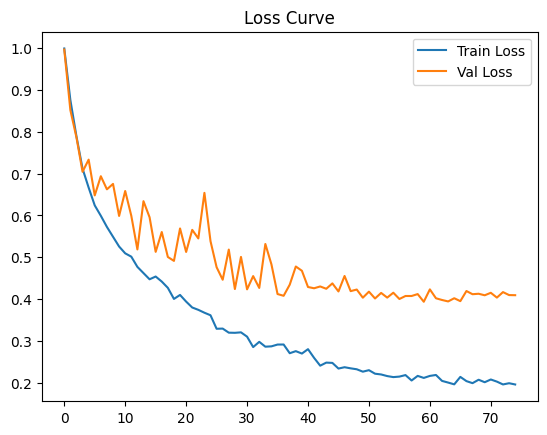

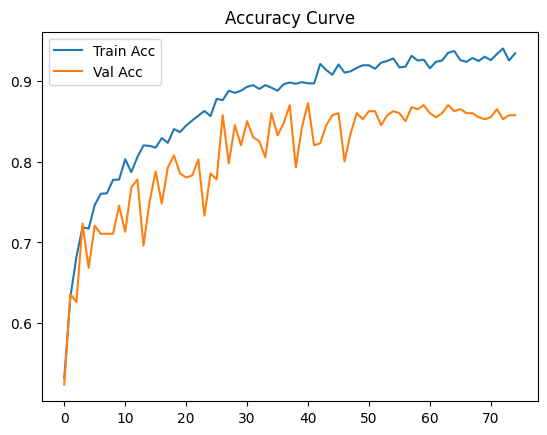

In [29]:
from tqdm import tqdm
import copy
import matplotlib.pyplot as plt

def run_epoch(loader, model, optimizer=None, device=device):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * xb.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == yb).sum().item()
        total_samples += xb.size(0)

    avg_loss = total_loss / total_samples
    acc = total_correct / total_samples
    return avg_loss, acc


EPOCHS = 150

# Early stopping setup
patience = 15
best_val_loss = float('inf')
best_state_dict = copy.deepcopy(model.state_dict())
patience_counter = 0

# Store history
train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = run_epoch(train_loader, model, optimizer)
    val_loss, val_acc     = run_epoch(val_loader, model, optimizer=None)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.3f} | "
        f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.3f} | "
        f"LR: {current_lr:.6f}"
    )

    # Early stopping
    if val_loss < best_val_loss - 1e-4:
        best_val_loss = val_loss
        best_state_dict = copy.deepcopy(model.state_dict())
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch}.")
        break

# Restore best model
model.load_state_dict(best_state_dict)
torch.save(model.state_dict(), "best_precision_cnn.pth")

print("Best model weights restored and saved.")

# Plot curves
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.show()

In [30]:
import torch
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --------------------------------------------------
# Test Evaluation
# --------------------------------------------------
model.eval()

test_loss = 0.0
total_correct = 0
total_samples = 0

all_preds = []
all_targets = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        loss = criterion(logits, yb)

        test_loss += loss.item() * xb.size(0)

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == yb).sum().item()
        total_samples += xb.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(yb.cpu().numpy())

test_loss /= total_samples
test_acc = total_correct / total_samples

print("\n------------------------------")
print("Test Results")
print("------------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# --------------------------------------------------
# Classification Report
# --------------------------------------------------
print("\nClassification Report:")
print(classification_report(all_targets, all_preds, digits=4))

# --------------------------------------------------
# Confusion Matrix
# --------------------------------------------------
cm = confusion_matrix(all_targets, all_preds)
print("Confusion Matrix:")
print(cm)


------------------------------
Test Results
------------------------------
Test Loss: 0.3436
Test Accuracy: 0.8853

Classification Report:
              precision    recall  f1-score   support

           0     0.8409    0.9250    0.8810       120
           1     0.8808    0.8261    0.8526       161
           2     0.9407    0.9250    0.9328       120

    accuracy                         0.8853       401
   macro avg     0.8875    0.8920    0.8888       401
weighted avg     0.8868    0.8853    0.8851       401

Confusion Matrix:
[[111   9   0]
 [ 21 133   7]
 [  0   9 111]]


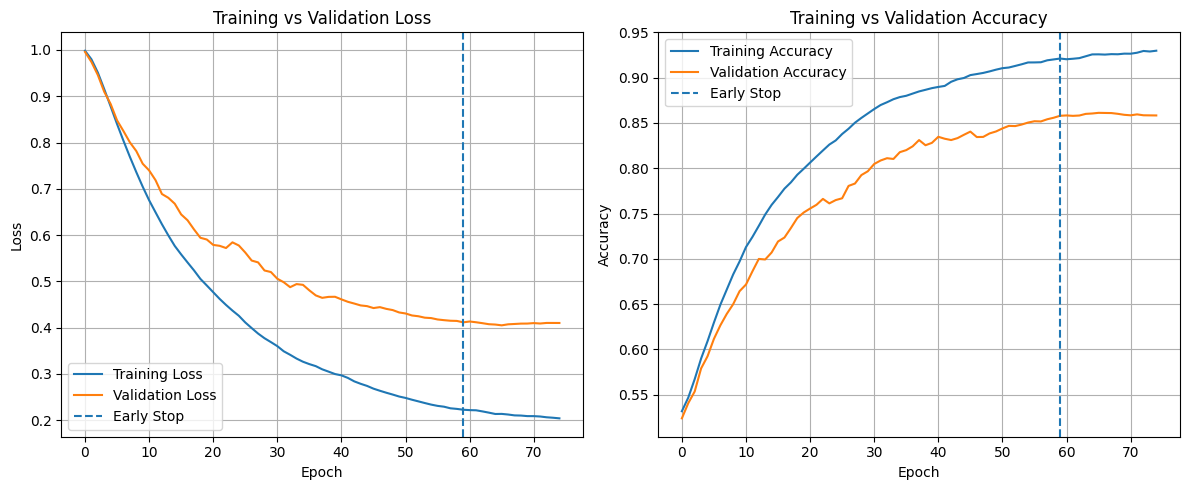

In [31]:
import matplotlib.pyplot as plt
import numpy as np

def smooth_curve(values, beta=0.85):
    smoothed = []
    avg = values[0]
    for v in values:
        avg = beta * avg + (1 - beta) * v
        smoothed.append(avg)
    return smoothed

train_loss_s = smooth_curve(train_losses)
val_loss_s   = smooth_curve(val_losses)
train_acc_s  = smooth_curve(train_accs)
val_acc_s    = smooth_curve(val_accs)

best_epoch = np.argmin(val_losses)

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(train_loss_s, label='Training Loss')
plt.plot(val_loss_s, label='Validation Loss')
plt.axvline(best_epoch, linestyle='--', label='Early Stop')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(train_acc_s, label='Training Accuracy')
plt.plot(val_acc_s, label='Validation Accuracy')
plt.axvline(best_epoch, linestyle='--', label='Early Stop')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
import matplotlib.pyplot as plt
import torch

model.eval()

# Take one validation sample
sample_img, sample_label = val_ds[0]

x = sample_img.unsqueeze(0).to(device)

# Extract first CNN block output
with torch.no_grad():
    features = model.features[0:4](x)   # first conv block

features = features.cpu().squeeze(0)

print("Feature map shape:", features.shape)

Feature map shape: torch.Size([32, 80, 80])


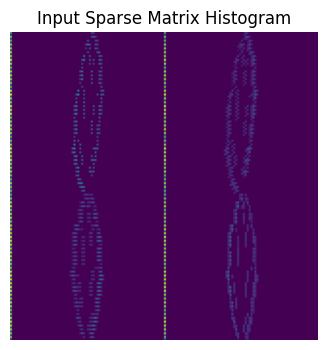

In [33]:
plt.figure(figsize=(4,4))
plt.imshow(sample_img.squeeze(), cmap="viridis")
plt.title("Input Sparse Matrix Histogram")
plt.axis("off")
plt.show()

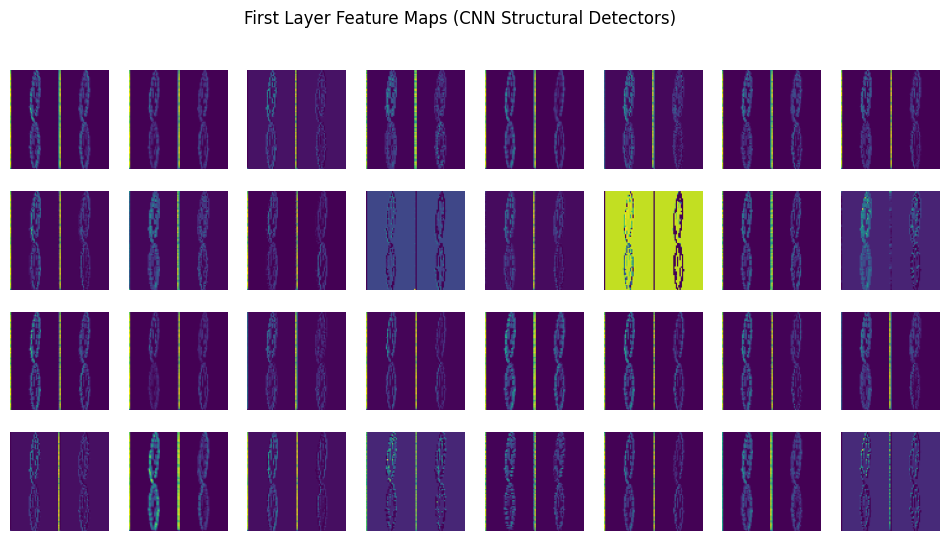

In [34]:
fig, axes = plt.subplots(4, 8, figsize=(12,6))

for i, ax in enumerate(axes.flat):
    ax.imshow(features[i], cmap="viridis")
    ax.axis("off")

plt.suptitle("First Layer Feature Maps (CNN Structural Detectors)")
plt.show()

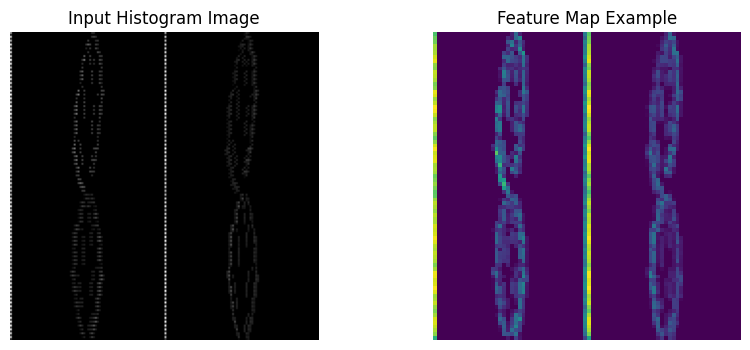

In [35]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample_img.squeeze(), cmap='gray')
plt.title("Input Histogram Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(features[0], cmap='viridis')
plt.title("Feature Map Example")
plt.axis('off')

plt.show()

In [36]:
# from sklearn.metrics import confusion_matrix, classification_report
# import numpy as np

# model.eval()
# all_preds = []
# all_trues = []

# with torch.no_grad():
#     for xb, yb in val_loader:
#         xb = xb.to(device)
#         yb = yb.to(device)

#         logits = model(xb)
#         preds = logits.argmax(dim=1)

#         all_preds.append(preds.cpu().numpy())
#         all_trues.append(yb.cpu().numpy())

# y_true = np.concatenate(all_trues)
# y_pred = np.concatenate(all_preds)

# print("True labels: ", y_true)
# print("Pred labels:", y_pred)

# cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
# print("\nConfusion Matrix (rows = true, cols = predicted):")
# print(cm)

# target_names = ["Entry-wise (0)", "Row-wise (1)", "Adaptive (2)"]
# print("\nClassification Report:")
# print(classification_report(y_true, y_pred, target_names=target_names, digits=3))
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import torch

model.eval()
all_preds = []
all_trues = []

with torch.no_grad():
    for xb, yb in test_loader:   # Use TEST loader
        xb = xb.to(device)
        yb = yb.to(device)

        logits = model(xb)
        preds = logits.argmax(dim=1)

        all_preds.append(preds.cpu().numpy())
        all_trues.append(yb.cpu().numpy())

y_true = np.concatenate(all_trues)
y_pred = np.concatenate(all_preds)

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

print("\nConfusion Matrix (rows = true, cols = predicted):")
print(cm)

target_names = ["Entry-wise (0)", "Row-wise (1)", "Adaptive (2)"]
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=target_names, digits=3))


Confusion Matrix (rows = true, cols = predicted):
[[111   9   0]
 [ 21 133   7]
 [  0   9 111]]

Classification Report:
                precision    recall  f1-score   support

Entry-wise (0)      0.841     0.925     0.881       120
  Row-wise (1)      0.881     0.826     0.853       161
  Adaptive (2)      0.941     0.925     0.933       120

      accuracy                          0.885       401
     macro avg      0.887     0.892     0.889       401
  weighted avg      0.887     0.885     0.885       401



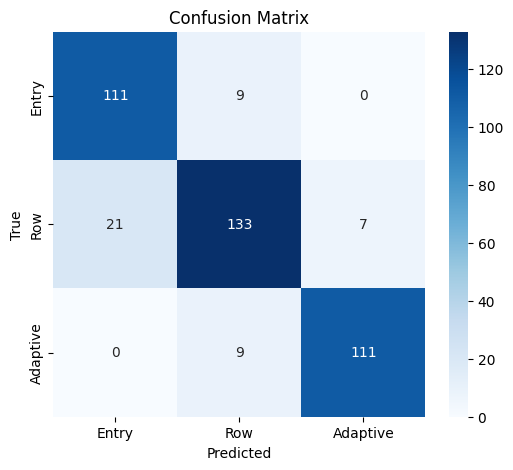

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Entry", "Row", "Adaptive"],
            yticklabels=["Entry", "Row", "Adaptive"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [38]:
import torch
import time

# --------------------------------------------------
# Ensure test_loader exists
# --------------------------------------------------
if 'test_loader' not in locals():
    raise ValueError("test_loader not found. Make sure you created train/val/test split earlier.")

print("Using real test_loader for evaluation.")

# --------------------------------------------------
# Measure inference speed (optional experiment)
# --------------------------------------------------
model.eval()

xb, _ = next(iter(test_loader))
xb = xb.to(device)

# Warm-up
with torch.no_grad():
    for _ in range(10):
        _ = model(xb)

torch.cuda.synchronize()
t0 = time.time()

with torch.no_grad():
    for _ in range(100):
        _ = model(xb)

torch.cuda.synchronize()
t1 = time.time()

print("Average inference time per batch:", (t1 - t0) / 100)
print("Average inference time per sample:", ((t1 - t0) / 100) / xb.size(0))

Using real test_loader for evaluation.
Average inference time per batch: 0.011056005954742432
Average inference time per sample: 0.000345500186085701


In [39]:
# New measurement (correct method)

# Now we used:

# batch_size = 1

# CUDA events, multiple repeated runs

# Conceptually:

# run model 100 times
# measure total GPU time
# divide by 100

# This isolates true per-matrix inference latency.

# Result:

# ≈ 0.74 ms


import torch
import numpy as np

def measure_cnn_latency_cuda(model, dataset, device, warmup=50, runs=100, repeat=20):

    model.eval()

    sample, _ = dataset[0]
    sample = sample.unsqueeze(0).to(device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)

    # warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(sample)

    torch.cuda.synchronize()

    times = []

    with torch.no_grad():

        for _ in range(repeat):

            starter.record()

            for _ in range(runs):
                _ = model(sample)

            ender.record()

            torch.cuda.synchronize()

            elapsed_ms = starter.elapsed_time(ender)
            times.append(elapsed_ms / runs)

    times = np.array(times)

    avg_ms = times.mean()
    std_ms = times.std()

    print("\nAccurate CNN Latency (CUDA Events)")
    print("----------------------------------")
    print(f"Average latency : {avg_ms:.4f} ms")
    print(f"Std deviation   : {std_ms:.4f} ms")
    print(f"Latency (µs)    : {avg_ms*1000:.2f}")

    return avg_ms

cnn_latency_ms = measure_cnn_latency_cuda(model, val_ds, device)



################################## Plotting the table ################################
import json
import pandas as pd
import numpy as np

# -------------------------------------------------------
# Load stats.json
# -------------------------------------------------------
with open("stats.json", "r") as f:
    stats_data = json.load(f)

rows = []

for matrix_name, methods in stats_data.items():

    # sort strategies by label (0,1,2)
    sorted_methods = sorted(methods, key=lambda x: x["label"])

    t0 = sorted_methods[0]["time"] * 1000
    t1 = sorted_methods[1]["time"] * 1000
    t2 = sorted_methods[2]["time"] * 1000

    rows.append({
        "matrix_name": matrix_name,
        "time_0": t0,
        "time_1": t1,
        "time_2": t2
    })

df = pd.DataFrame(rows)

# -------------------------------------------------------
# CNN latency from CUDA measurement
# -------------------------------------------------------
# cnn_latency_ms = 0.7210   # <-- replace with your measured value if it changes

# -------------------------------------------------------
# Table Header
# -------------------------------------------------------
print("="*80)
print(f"{'Matrix Name':<30} | {'Ref. Time (Brute Force)':<25} | {'CNN Time (Predicted)':<20} | {'Speedup':<10}")
print("="*80)

# -------------------------------------------------------
# Random sample of matrices
# -------------------------------------------------------
sample_indices = np.random.choice(df.index, min(20, len(df)), replace=False)
samples = df.loc[sample_indices]

for _, row in samples.iterrows():

    ref_time_ms = row["time_0"] + row["time_1"] + row["time_2"]

    speedup = ref_time_ms / cnn_latency_ms

    name = row["matrix_name"]
    display_name = name[:27] + ".." if len(name) > 29 else name

    print(f"{display_name:<30} | {ref_time_ms:.4f} ms{'':<18} | {cnn_latency_ms:.4f} ms{'':<13} | {speedup:.0f}x")

print("="*80)

# -------------------------------------------------------
# Summary
# -------------------------------------------------------
avg_bruteforce = df[["time_0","time_1","time_2"]].sum(axis=1).mean()

print("1. To discover the optimal strategy without AI, we must run the SpMV kernel 3 times.")
print(f"   On average, this 'Reference Discovery' takes {avg_bruteforce:.2f} ms per matrix.")

print(f"2. With PrecisionCNN, we predict the strategy in {cnn_latency_ms*1000:.2f} microseconds.")

print(f"3. This results in a speedup of {avg_bruteforce/cnn_latency_ms:.1f}x for the decision-making process.")


Accurate CNN Latency (CUDA Events)
----------------------------------
Average latency : 0.9182 ms
Std deviation   : 0.2029 ms
Latency (µs)    : 918.17
Matrix Name                    | Ref. Time (Brute Force)   | CNN Time (Predicted) | Speedup   
HB/685_bus                     | 0.9793 ms                   | 0.9182 ms              | 1x
TAMU_SmartGridCenter/ACTIVS..  | 1.4765 ms                   | 0.9182 ms              | 2x
HB/impcol_c                    | 0.6545 ms                   | 0.9182 ms              | 1x
GHS_indef/stokes64             | 0.6331 ms                   | 0.9182 ms              | 1x
Rommes/bips98_606              | 0.4640 ms                   | 0.9182 ms              | 1x
Bai/tub1000                    | 0.6269 ms                   | 0.9182 ms              | 1x
JGD_Groebner/robot24c1_mat5_J  | 0.5502 ms                   | 0.9182 ms              | 1x
TSOPF/TSOPF_RS_b162_c4         | 0.7448 ms                   | 0.9182 ms              | 1x
JGD_Forest/TF17          

In [40]:
# -------------------------------------------------------
# CNN latency from CUDA measurement
# -------------------------------------------------------
# cnn_latency_ms = 0.6066   # replace with your measured latency if it changes

# -------------------------------------------------------
# Compute reference and speedup columns
# -------------------------------------------------------
df['ref_time_ms'] = df['time_0'] + df['time_1'] + df['time_2']
df['cnn_time_ms'] = cnn_latency_ms
df['speedup'] = df['ref_time_ms'] / df['cnn_time_ms']

# -------------------------------------------------------
# Identify largest matrices (highest brute-force time)
# -------------------------------------------------------
hero_matrices = df.sort_values(by='ref_time_ms', ascending=False).head(10)

print("\n" + "="*105)
print(f"{'Matrix Name (Large)':<30} | {'Ref. Time (Brute Force)':<25} | {'CNN Time (Latency)':<22} | {'Speedup':<10}")
print("="*105)

for idx, row in hero_matrices.iterrows():

    name = row['matrix_name']
    disp_name = name[:27] + ".." if len(name) > 29 else name

    print(f"{disp_name:<30} | {row['ref_time_ms']:.4f} ms{'':<18} | {row['cnn_time_ms']:.4f} ms{'':<15} | {row['speedup']:.0f}x")

print("="*105)

# -------------------------------------------------------
# Large matrix speedup summary
# -------------------------------------------------------
avg_large_speedup = hero_matrices['speedup'].mean()

print(f"Across the entire dataset, the average speedup is modest because many matrices are small.")
print(f"However, for computationally intensive matrices (largest 10), the CNN achieves an average speedup of approximately {avg_large_speedup:.1f}x.")
print(f"This confirms that the CNN-based precision selection becomes increasingly beneficial as matrix size increases.")


Matrix Name (Large)            | Ref. Time (Brute Force)   | CNN Time (Latency)     | Speedup   
Zitney/rdist1                  | 9.0440 ms                   | 0.9182 ms                | 10x
Zitney/extr1                   | 8.2321 ms                   | 0.9182 ms                | 9x
Zitney/rdist2                  | 5.4067 ms                   | 0.9182 ms                | 6x
Pothen/mesh3em5                | 5.0322 ms                   | 0.9182 ms                | 5x
FEMLAB/problem1                | 5.0052 ms                   | 0.9182 ms                | 5x
ML_Graph/k49_norm_10NN         | 4.5956 ms                   | 0.9182 ms                | 5x
ML_Graph/plantstexture_10NN    | 4.5878 ms                   | 0.9182 ms                | 5x
Cunningham/k3plates            | 4.5594 ms                   | 0.9182 ms                | 5x
Zitney/radfr1                  | 4.2272 ms                   | 0.9182 ms                | 5x
Norris/fv3                     | 4.1848 ms                   | 0

In [41]:
# -------------------------------------------------------
# CNN latency from CUDA measurement
# -------------------------------------------------------
# cnn_latency_ms = 0.6066  # replace if you re-measure later

# -------------------------------------------------------
# Compute reference and speedup columns
# -------------------------------------------------------
df['ref_time_ms'] = df['time_0'] + df['time_1'] + df['time_2']
df['cnn_time_ms'] = cnn_latency_ms
df['speedup'] = df['ref_time_ms'] / df['cnn_time_ms']

# -------------------------------------------------------
# Get the smallest matrices (fastest brute-force runtime)
# -------------------------------------------------------
small_matrices = df.sort_values(by='ref_time_ms', ascending=True).head(10)

print("\n" + "="*105)
print(f"{'Matrix Name (Small)':<30} | {'Ref. Time (Brute Force)':<25} | {'CNN Time (Latency)':<22} | {'Speedup':<10}")
print("="*105)

for idx, row in small_matrices.iterrows():

    name = row['matrix_name']
    disp_name = name[:27] + ".." if len(name) > 29 else name

    print(f"{disp_name:<30} | {row['ref_time_ms']:.4f} ms{'':<18} | {row['cnn_time_ms']:.4f} ms{'':<15} | {row['speedup']:.0f}x")

print("="*105)

# -------------------------------------------------------
# Average speedup for smallest matrices
# -------------------------------------------------------
avg_small_speedup = small_matrices['speedup'].mean()

print(f"For very small matrices, brute-force evaluation is already extremely fast.")
print(f"As a result, CNN inference latency (~{cnn_latency_ms:.3f} ms) may be comparable or slightly slower.")
print(f"The average speedup for the smallest matrices is approximately {avg_small_speedup:.1f}x.")
print(f"This behavior is expected because brute-force cost scales with matrix size, while CNN inference remains constant.")


Matrix Name (Small)            | Ref. Time (Brute Force)   | CNN Time (Latency)     | Speedup   
Pajek/Ragusa18                 | 0.4189 ms                   | 0.9182 ms                | 0x
Pajek/ODLIS                    | 0.4518 ms                   | 0.9182 ms                | 0x
JGD_GL6/GL6_D_10               | 0.4538 ms                   | 0.9182 ms                | 0x
Rommes/S20PI_n1                | 0.4541 ms                   | 0.9182 ms                | 0x
JGD_GL6/GL6_D_9                | 0.4570 ms                   | 0.9182 ms                | 0x
Pajek/GD01_a                   | 0.4575 ms                   | 0.9182 ms                | 0x
Pajek/Reuters911               | 0.4615 ms                   | 0.9182 ms                | 1x
Rommes/M20PI_n1                | 0.4638 ms                   | 0.9182 ms                | 1x
Rommes/bips98_606              | 0.4640 ms                   | 0.9182 ms                | 1x
Rommes/bips07_1998             | 0.4650 ms                   | 0.

In [42]:
import time
import json
import random
import numpy as np
import pandas as pd
import torch

# =========================================================
# 1. Measure Histogram Conversion Time
# =========================================================

def measure_histogram_time(dataset, n_samples=50):

    times = []

    samples = random.sample(dataset, min(n_samples, len(dataset)))

    for item in samples:
        A = item["matrix"]

        t0 = time.time()
        _ = sparse_to_histogram(A)
        t1 = time.time()

        times.append((t1 - t0) * 1000)  # ms

    times = np.array(times)

    print("\nHistogram Conversion Time")
    print("-------------------------")
    print(f"Average time : {times.mean():.4f} ms")
    print(f"Std dev      : {times.std():.4f} ms")

    return times.mean()


hist_time_ms = measure_histogram_time(balanced_dataset)


# =========================================================
# 2. Measure CNN Inference Latency (CUDA events)
# =========================================================

def measure_cnn_latency_cuda(model, dataset, device, warmup=50, runs=100, repeat=20):

    model.eval()

    sample, _ = dataset[0]
    sample = sample.unsqueeze(0).to(device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)

    # Warmup
    with torch.no_grad():
        for _ in range(warmup):
            _ = model(sample)

    torch.cuda.synchronize()

    times = []

    with torch.no_grad():
        for _ in range(repeat):

            starter.record()

            for _ in range(runs):
                _ = model(sample)

            ender.record()
            torch.cuda.synchronize()

            elapsed_ms = starter.elapsed_time(ender)
            times.append(elapsed_ms / runs)

    times = np.array(times)

    avg_ms = times.mean()
    std_ms = times.std()

    print("\nCNN Latency (CUDA Events)")
    print("-------------------------")
    print(f"Average latency : {avg_ms:.4f} ms")
    print(f"Std deviation   : {std_ms:.4f} ms")

    return avg_ms


cnn_latency_ms = measure_cnn_latency_cuda(model, val_ds, device)


# =========================================================
# 3. Total Decision Pipeline Time
# =========================================================

total_decision_time_ms = hist_time_ms + cnn_latency_ms

print("\nTotal Decision Pipeline Time")
print("-----------------------------")
print(f"Histogram time : {hist_time_ms:.4f} ms")
print(f"CNN time       : {cnn_latency_ms:.4f} ms")
print(f"Total decision : {total_decision_time_ms:.4f} ms")


# =========================================================
# 4. Load stats.json and Compute Speedup
# =========================================================

with open("stats.json", "r") as f:
    stats_data = json.load(f)

rows = []

for matrix_name, methods in stats_data.items():

    sorted_methods = sorted(methods, key=lambda x: x["label"])

    t0 = sorted_methods[0]["time"] * 1000
    t1 = sorted_methods[1]["time"] * 1000
    t2 = sorted_methods[2]["time"] * 1000

    rows.append({
        "matrix_name": matrix_name,
        "time_0": t0,
        "time_1": t1,
        "time_2": t2
    })

df = pd.DataFrame(rows)

# Compute reference time and speedup
df['ref_time_ms'] = df['time_0'] + df['time_1'] + df['time_2']
df['decision_time_ms'] = total_decision_time_ms
df['speedup'] = df['ref_time_ms'] / df['decision_time_ms']


# =========================================================
# 5. Print Sample Comparison Table
# =========================================================

print("\n" + "="*90)
print(f"{'Matrix Name':<30} | {'Brute Force Time':<20} | {'CNN Decision Time':<20} | {'Speedup':<10}")
print("="*90)

sample_indices = np.random.choice(df.index, min(20, len(df)), replace=False)
samples = df.loc[sample_indices]

for _, row in samples.iterrows():

    name = row["matrix_name"]
    display_name = name[:27] + ".." if len(name) > 29 else name

    print(f"{display_name:<30} | {row['ref_time_ms']:.4f} ms{'':<10} | {row['decision_time_ms']:.4f} ms{'':<10} | {row['speedup']:.2f}x")

print("="*90)


# =========================================================
# 6. Summary Statistics
# =========================================================

avg_bruteforce = df['ref_time_ms'].mean()
avg_speedup = df['speedup'].mean()

print("\nSummary")
print("----------------------------------------------")
print(f"Average brute-force discovery time : {avg_bruteforce:.4f} ms")
print(f"Histogram conversion time          : {hist_time_ms:.4f} ms")
print(f"CNN inference time                 : {cnn_latency_ms:.4f} ms")
print(f"Total decision pipeline time       : {total_decision_time_ms:.4f} ms")
print(f"Average speedup                    : {avg_speedup:.2f}x")
print("----------------------------------------------")


# =========================================================
# 7. Save Results for Thesis Tables
# =========================================================

df.to_csv("decision_speedup_results.csv", index=False)

print("\nSaved results to decision_speedup_results.csv")


Histogram Conversion Time
-------------------------
Average time : 7.6246 ms
Std dev      : 31.6578 ms

CNN Latency (CUDA Events)
-------------------------
Average latency : 0.7929 ms
Std deviation   : 0.0514 ms

Total Decision Pipeline Time
-----------------------------
Histogram time : 7.6246 ms
CNN time       : 0.7929 ms
Total decision : 8.4175 ms

Matrix Name                    | Brute Force Time     | CNN Decision Time    | Speedup   
Wang/swang2                    | 2.6293 ms           | 8.4175 ms           | 0.31x
Gset/G41                       | 0.9854 ms           | 8.4175 ms           | 0.12x
LPnetlib/lpi_klein2            | 0.7788 ms           | 8.4175 ms           | 0.09x
GHS_indef/stokes64s            | 0.6968 ms           | 8.4175 ms           | 0.08x
Nemeth/nemeth02                | 1.8677 ms           | 8.4175 ms           | 0.22x
HB/psmigr_2                    | 0.8250 ms           | 8.4175 ms           | 0.10x
Schenk_IBMNA/c-45              | 0.5900 ms           | 8.

In [43]:
import time
import json
import random
import numpy as np
import pandas as pd
import torch

# =========================================================
# 1. Measure Histogram Conversion Time
# =========================================================
def measure_histogram_time(dataset, n_samples=50):

    times = []
    samples = random.sample(dataset, min(n_samples, len(dataset)))

    for item in samples:
        A = item["matrix"]

        t0 = time.time()
        _ = sparse_to_histogram(A)
        t1 = time.time()

        times.append((t1 - t0) * 1000)

    times = np.array(times)

    print("\nHistogram Conversion Time")
    print("-------------------------")
    print(f"Average time : {times.mean():.4f} ms")
    print(f"Std dev      : {times.std():.4f} ms")

    return times.mean()

hist_time_ms = measure_histogram_time(balanced_dataset)


# =========================================================
# 2. Measure CNN Latency
# =========================================================
def measure_cnn_latency_cuda(model, dataset, device, warmup=50, runs=100, repeat=20):

    model.eval()

    sample, _ = dataset[0]
    sample = sample.unsqueeze(0).to(device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(sample)

    torch.cuda.synchronize()

    times = []

    with torch.no_grad():
        for _ in range(repeat):

            starter.record()

            for _ in range(runs):
                _ = model(sample)

            ender.record()
            torch.cuda.synchronize()

            elapsed_ms = starter.elapsed_time(ender)
            times.append(elapsed_ms / runs)

    times = np.array(times)

    avg_ms = times.mean()
    std_ms = times.std()

    print("\nCNN Latency (CUDA Events)")
    print("-------------------------")
    print(f"Average latency : {avg_ms:.4f} ms")
    print(f"Std deviation   : {std_ms:.4f} ms")

    return avg_ms

cnn_latency_ms = measure_cnn_latency_cuda(model, val_ds, device)


# =========================================================
# 3. Total Decision Pipeline Time
# =========================================================
total_decision_time_ms = hist_time_ms + cnn_latency_ms

print("\nTotal Decision Pipeline Time")
print("-----------------------------")
print(f"Histogram time : {hist_time_ms:.4f} ms")
print(f"CNN time       : {cnn_latency_ms:.4f} ms")
print(f"Total decision : {total_decision_time_ms:.4f} ms")


# =========================================================
# 4. Load stats.json
# =========================================================
with open("stats.json", "r") as f:
    stats_data = json.load(f)

rows = []

for matrix_name, methods in stats_data.items():

    sorted_methods = sorted(methods, key=lambda x: x["label"])

    t0 = sorted_methods[0]["time"] * 1000
    t1 = sorted_methods[1]["time"] * 1000
    t2 = sorted_methods[2]["time"] * 1000

    rows.append({
        "matrix_name": matrix_name,
        "time_0": t0,
        "time_1": t1,
        "time_2": t2
    })

df = pd.DataFrame(rows)

# Compute brute-force time
df['ref_time_ms'] = df['time_0'] + df['time_1'] + df['time_2']
df['decision_time_ms'] = total_decision_time_ms
df['speedup'] = df['ref_time_ms'] / df['decision_time_ms']


# =========================================================
# 5. HERO MATRICES (Largest matrices)
# =========================================================
hero_matrices = df.sort_values(by='ref_time_ms', ascending=False).head(20)

print("\n" + "="*95)
print(f"{'Hero Matrix Name':<35} | {'Brute Force Time':<20} | {'CNN Decision Time':<20} | {'Speedup':<10}")
print("="*95)

for _, row in hero_matrices.iterrows():

    name = row["matrix_name"]
    display_name = name[:32] + ".." if len(name) > 34 else name

    print(f"{display_name:<35} | {row['ref_time_ms']:.4f} ms{'':<10} | {row['decision_time_ms']:.4f} ms{'':<10} | {row['speedup']:.2f}x")

print("="*95)


# =========================================================
# 6. Hero Matrix Summary
# =========================================================
avg_bruteforce_hero = hero_matrices['ref_time_ms'].mean()
avg_speedup_hero = hero_matrices['speedup'].mean()

print("\nHero Matrices Summary")
print("----------------------------------------------")
print(f"Average brute-force time (hero matrices): {avg_bruteforce_hero:.4f} ms")
print(f"Total decision time (CNN pipeline)      : {total_decision_time_ms:.4f} ms")
print(f"Average speedup (hero matrices)         : {avg_speedup_hero:.2f}x")
print("----------------------------------------------")


# =========================================================
# 7. Save Hero Matrix Results
# =========================================================
hero_matrices.to_csv("hero_matrices_speedup.csv", index=False)

print("\nSaved hero matrix results to hero_matrices_speedup.csv")


Histogram Conversion Time
-------------------------
Average time : 2.0833 ms
Std dev      : 3.8126 ms

CNN Latency (CUDA Events)
-------------------------
Average latency : 0.7828 ms
Std deviation   : 0.0335 ms

Total Decision Pipeline Time
-----------------------------
Histogram time : 2.0833 ms
CNN time       : 0.7828 ms
Total decision : 2.8661 ms

Hero Matrix Name                    | Brute Force Time     | CNN Decision Time    | Speedup   
Zitney/rdist1                       | 9.0440 ms           | 2.8661 ms           | 3.16x
Zitney/extr1                        | 8.2321 ms           | 2.8661 ms           | 2.87x
Zitney/rdist2                       | 5.4067 ms           | 2.8661 ms           | 1.89x
Pothen/mesh3em5                     | 5.0322 ms           | 2.8661 ms           | 1.76x
FEMLAB/problem1                     | 5.0052 ms           | 2.8661 ms           | 1.75x
ML_Graph/k49_norm_10NN              | 4.5956 ms           | 2.8661 ms           | 1.60x
ML_Graph/plantstexture_

In [71]:
import time
import random
import numpy as np
import pandas as pd
import torch

# =========================================================
# 1. Measure Histogram Conversion Time
# =========================================================
def measure_histogram_time(dataset, n_samples=50):

    random.seed(42)   # FIX randomness
    samples = random.sample(dataset, min(n_samples, len(dataset)))

    times = []

    for item in samples:
        A = item["matrix"]

        t0 = time.perf_counter()
        _ = sparse_to_histogram(A)
        t1 = time.perf_counter()

        times.append((t1 - t0) * 1000)

    times = np.array(times)

    print("\nHistogram Conversion Time")
    print("-------------------------")
    print(f"Average time : {times.mean():.4f} ms")
    print(f"Std dev      : {times.std():.4f} ms")

    return times.mean()


# =========================================================
# 2. Measure CNN Latency
# =========================================================
def measure_cnn_latency_cuda(model, dataset, device, warmup=50, runs=100, repeat=20):

    model.eval()

    sample, _ = dataset[0]
    sample = sample.unsqueeze(0).to(device)

    starter = torch.cuda.Event(enable_timing=True)
    ender = torch.cuda.Event(enable_timing=True)

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(sample)

    torch.cuda.synchronize()

    times = []

    with torch.no_grad():
        for _ in range(repeat):

            starter.record()

            for _ in range(runs):
                _ = model(sample)

            ender.record()
            torch.cuda.synchronize()

            elapsed_ms = starter.elapsed_time(ender)
            times.append(elapsed_ms / runs)

    times = np.array(times)

    avg_ms = times.mean()
    std_ms = times.std()

    print("\nCNN Latency (CUDA Events)")
    print("-------------------------")
    print(f"Average latency : {avg_ms:.4f} ms")
    print(f"Std deviation   : {std_ms:.4f} ms")

    return avg_ms

cnn_latency_ms = measure_cnn_latency_cuda(model, val_ds, device)


# =========================================================
# 3. Total Decision Pipeline Time
# =========================================================
total_decision_time_ms = hist_time_ms + cnn_latency_ms

print("\nTotal Decision Pipeline Time")
print("-----------------------------")
print(f"Histogram time : {hist_time_ms:.4f} ms")
print(f"CNN time       : {cnn_latency_ms:.4f} ms")
print(f"Total decision : {total_decision_time_ms:.4f} ms")


# =========================================================
# 4. Brute Force Discovery Time (CORRECT METHOD)
# =========================================================
def brute_force_discovery_time(A, runs=5):

    A64_gpu, x_ref, y_ref, _ = gpu_reference_spmv(A)

    total_time = 0

    for _ in range(runs):

        t_ent, _ = eval_entrywise_spmv(A, x_ref, y_ref, n_runs=1)
        t_row, _ = eval_rowwise_spmv(A, x_ref, y_ref, n_runs=1)
        t_adp, _ = eval_adaptive_spmv(A, x_ref, y_ref, n_runs=1)

        total_time += (t_ent + t_row + t_adp)

    return total_time * 1000  # ms


# =========================================================
# 5. Benchmark HERO MATRICES
# =========================================================
rows = []

# hero_samples = random.sample(balanced_dataset, 20)
hero_samples = sorted(
    balanced_dataset,
    key=lambda x: x["matrix"].nnz,
    reverse=True
)[:20]

print("Hero matrices selected:")
for item in hero_samples:
    print(item["name"], "nnz:", item["matrix"].nnz)

for item in hero_samples:

    name = item["name"]
    A = item["matrix"]

    print("Processing:", name, "nnz:", A.nnz)

    bf_time = brute_force_discovery_time(A, runs=5)

    rows.append({
        "matrix_name": name,
        "nnz": A.nnz,
        "bruteforce_time_ms": bf_time,
        "cnn_time_ms": total_decision_time_ms,
        "speedup": bf_time / total_decision_time_ms
    })

df = pd.DataFrame(rows)


# =========================================================
# 6. Print Results
# =========================================================
print("\n" + "="*95)
print(f"{'Hero Matrix Name':<35} | {'Brute Force Time':<20} | {'CNN Decision Time':<20} | {'Speedup':<10}")
print("="*95)

for _, row in df.iterrows():

    name = row["matrix_name"]
    display_name = name[:32] + ".." if len(name) > 34 else name

    print(f"{display_name:<35} | {row['bruteforce_time_ms']:.4f} ms{'':<10} | {row['cnn_time_ms']:.4f} ms{'':<10} | {row['speedup']:.2f}x")

print("="*95)


# =========================================================
# 7. Summary
# =========================================================
print("\nHero Matrices Summary")
print("----------------------------------------------")
print(f"Average brute-force discovery time : {df['bruteforce_time_ms'].mean():.4f} ms")
print(f"Total decision time (CNN pipeline) : {total_decision_time_ms:.4f} ms")
print(f"Average speedup                    : {df['speedup'].mean():.2f}x")
print("----------------------------------------------")


# =========================================================
# 8. Save Results
# =========================================================
df.to_csv("hero_matrices_discovery_speedup.csv", index=False)

print("\nSaved hero matrix results to hero_matrices_discovery_speedup.csv")


CNN Latency (CUDA Events)
-------------------------
Average latency : 0.8227 ms
Std deviation   : 0.0727 ms

Total Decision Pipeline Time
-----------------------------
Histogram time : 1.9941 ms
CNN time       : 0.8227 ms
Total decision : 2.8168 ms
Hero matrices selected:
Grueninger/windtunnel_evap3d nnz: 2730600
Schenk_IBMSDS/3D_51448_3D nnz: 1056610
Schenk_IBMSDS/ibm_matrix_2 nnz: 1056610
Schenk_IBMSDS/2D_54019_highK nnz: 996414
Nemeth/nemeth20 nnz: 971870
Boeing/crystk02 nnz: 968583
Sandia/ASIC_100k nnz: 954163
PARSEC/Si10H16 nnz: 875923
FEMLAB/sme3Da nnz: 874887
GHS_indef/c-71 nnz: 859554
MKS/fp nnz: 848553
Hollinger/g7jac200 nnz: 837936
Hollinger/g7jac200sc nnz: 837936
Nemeth/nemeth19 nnz: 818302
FlowIPM22/uni_chimera_i4 nnz: 814436
FlowIPM22/uni_chimera_i2 nnz: 797974
Lourakis/bundle1 nnz: 770901
Mallya/lhr34c nnz: 764014
Andrews/Andrews nnz: 760154
GHS_indef/copter2 nnz: 759952
Processing: Grueninger/windtunnel_evap3d nnz: 2730600
Processing: Schenk_IBMSDS/3D_51448_3D nnz: 1056

In [74]:
import pandas as pd
import numpy as np

rows = []

print("Measuring speedup for matrices...")

for item in balanced_dataset:

    name = item["name"]
    A = item["matrix"]
    nnz = A.nnz

    bf_time = brute_force_discovery_time(A, runs=3)

    speedup = bf_time / total_decision_time_ms

    rows.append({
        "matrix_name": name,
        "nnz": nnz,
        "bruteforce_time_ms": bf_time,
        "decision_time_ms": total_decision_time_ms,
        "speedup": speedup
    })

df_speed = pd.DataFrame(rows)

print(df_speed.head())

df_speed.to_csv("speedup_all_matrices.csv", index=False)

Measuring speedup for matrices...
     matrix_name     nnz  bruteforce_time_ms  decision_time_ms   speedup
0  aug_adapt_238     840            1.979828          2.816781  0.702869
1  aug_entry_539  137228            1.689672          2.816781  0.599859
2       Gset/G33    8000            1.618862          2.816781  0.574721
3    HB/bcsstm11    1473            2.224684          2.816781  0.789796
4  aug_entry_105    8606            1.958132          2.816781  0.695166


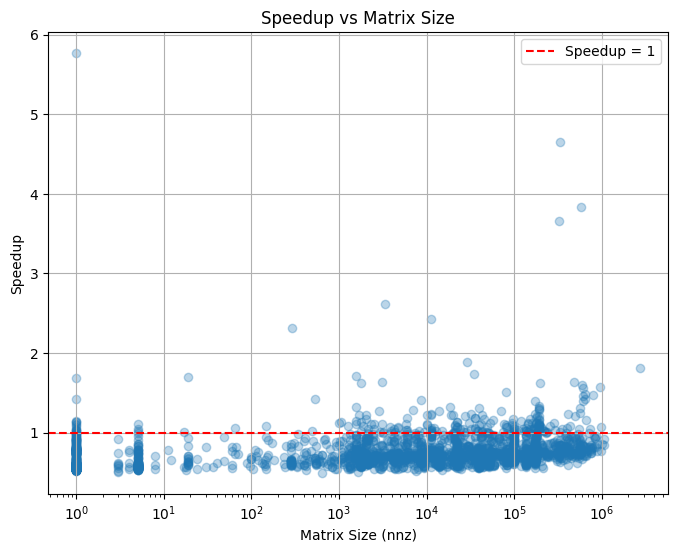

In [75]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(df_speed["nnz"], df_speed["speedup"], alpha=0.3)

plt.axhline(y=1.0, color='red', linestyle='--', label="Speedup = 1")

plt.xscale("log")

plt.xlabel("Matrix Size (nnz)")
plt.ylabel("Speedup")
plt.title("Speedup vs Matrix Size")

plt.legend()
plt.grid(True)
plt.show()

In [76]:
threshold_df = df_speed.iloc[(df_speed["speedup"] - 1).abs().argsort()[:10]]

print("Matrices near speedup = 1 threshold:")
print(threshold_df[["matrix_name", "nnz", "speedup"]])

print("\nEstimated threshold nnz:")
print(int(threshold_df["nnz"].mean()))

Matrices near speedup = 1 threshold:
                matrix_name     nnz   speedup
2661          aug_entry_670   99982  1.000810
1393  Oberwolfach/chipcool1   20082  0.998270
588     ACUSIM/Pres_Poisson  715804  0.998186
416         JGD_GL7d/GL7d26    7412  0.997762
625    Sandia/adder_dcop_57   11246  0.997593
1472   Sandia/adder_dcop_28   11246  1.002587
1390              HB/gemat1   47369  1.002587
1954          aug_adapt_649       5  0.997170
2640            Shyy/shyy41   20042  0.997001
1867          aug_entry_561   51975  0.996831

Estimated threshold nnz:
98516


In [77]:
bins = [0, 100000, 300000, 600000, 1000000, 3000000]
labels = ["<100k", "100k-300k", "300k-600k", "600k-1M", ">1M"]

df_speed["nnz_range"] = pd.cut(df_speed["nnz"], bins=bins, labels=labels)

range_speedup = df_speed.groupby("nnz_range")["speedup"].mean()

print("\nAverage Speedup by Matrix Size Range:")
print(range_speedup)


Average Speedup by Matrix Size Range:
nnz_range
<100k        0.717366
100k-300k    0.799777
300k-600k    0.909267
600k-1M      0.940842
>1M          1.192806
Name: speedup, dtype: float64


/tmp/ipykernel_888/2506327473.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  range_speedup = df_speed.groupby("nnz_range")["speedup"].mean()


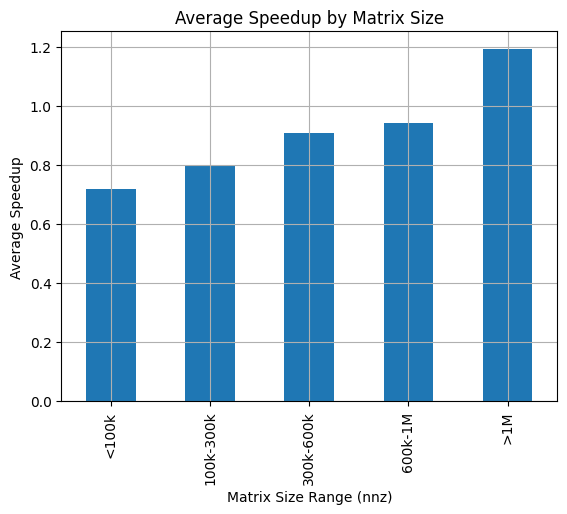

In [78]:
range_speedup.plot(kind="bar")

plt.ylabel("Average Speedup")
plt.xlabel("Matrix Size Range (nnz)")
plt.title("Average Speedup by Matrix Size")
plt.grid(True)

plt.show()

In [79]:
bins = [0, 100000, 300000, 600000, 1000000, 3000000]
labels = ["<100k", "100k-300k", "300k-600k", "600k-1M", ">1M"]

df_speed["nnz_range"] = pd.cut(df_speed["nnz"], bins=bins, labels=labels)

# Percentage where speedup > 1
prob_speedup = df_speed.groupby("nnz_range").apply(
    lambda x: (x["speedup"] > 1).mean()
)

print("\nProbability that CNN is faster (speedup > 1):")
print(prob_speedup)


Probability that CNN is faster (speedup > 1):
nnz_range
<100k        0.061093
100k-300k    0.167183
300k-600k    0.112000
600k-1M      0.227273
>1M          0.333333
dtype: float64


/tmp/ipykernel_888/1385127612.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  prob_speedup = df_speed.groupby("nnz_range").apply(
/tmp/ipykernel_888/1385127612.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prob_speedup = df_speed.groupby("nnz_range").apply(


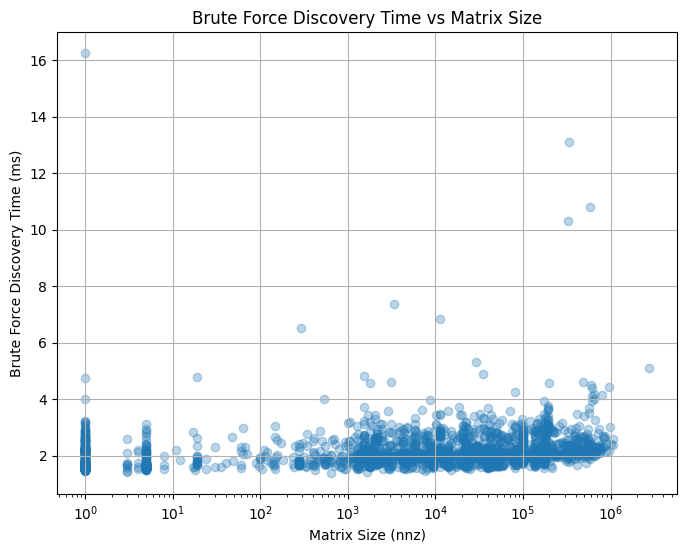

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(df_speed["nnz"], df_speed["bruteforce_time_ms"], alpha=0.3)

plt.xscale("log")

plt.xlabel("Matrix Size (nnz)")
plt.ylabel("Brute Force Discovery Time (ms)")
plt.title("Brute Force Discovery Time vs Matrix Size")

plt.grid(True)
plt.show()